## Self-Attention Learning Demo

Task: given a sequence of 2D vectors, train the self-attention layer to output the **mean** of all input vectors at every position.

A perfect solution is uniform attention weights (each token attends equally to all others), so the layer must learn W_q, W_k, W_v that produce that behaviour.

In [10]:
import sys
sys.path.insert(0, '..')

import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
from src.model.self_attention import SelfAttention, SelfAttentionConfig
import numpy as np

In [2]:
# --- Hyperparameters ---
N_SAMPLES  = 512   # training examples
SEQ_LEN    = 4     # tokens per sequence
D_X        = 2     # input / output dimension
LR         = 1e-2
EPOCHS     = 300

In [3]:
# --- Dataset ---
# X: random sequences of shape (N_SAMPLES, SEQ_LEN, D_X)
# Y: target is the mean vector broadcast to every position
torch.manual_seed(0)
X = torch.randn(N_SAMPLES, SEQ_LEN, D_X)
Y = X.mean(dim=1, keepdim=True).expand_as(X)  # (N, SEQ_LEN, D_X)

In [4]:
# --- Model & optimiser ---
config = SelfAttentionConfig(D_x=D_X, D_q=D_X, D_v=D_X)
model  = SelfAttention(config)
optim  = torch.optim.Adam(model.parameters(), lr=LR)

In [5]:
# --- Training loop ---
losses = []

for epoch in range(EPOCHS):
    # SelfAttention.forward expects (seq_len, D_x), so loop over the batch dim
    Y_pred = torch.stack([model(X[i]) for i in range(N_SAMPLES)])

    loss = F.mse_loss(Y_pred, Y)
    losses.append(loss.item())

    optim.zero_grad()
    loss.backward()
    optim.step()

    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:>4} | loss: {loss.item():.6f}")

Epoch   50 | loss: 0.067160
Epoch  100 | loss: 0.016547
Epoch  150 | loss: 0.004838
Epoch  200 | loss: 0.001099
Epoch  250 | loss: 0.000192
Epoch  300 | loss: 0.000026


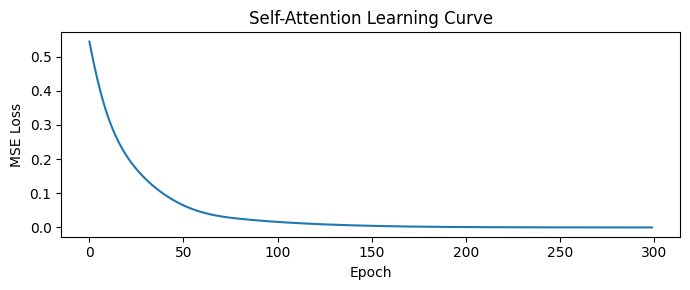

In [6]:
# --- Loss curve ---
plt.figure(figsize=(7, 3))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title('Self-Attention Learning Curve')
plt.tight_layout()
plt.show()

In [20]:
# --- Inspect a single example ---
model.eval()
with torch.no_grad():
    x_ex = X[0]                       # (SEQ_LEN, D_X)
    y_pred = model(x_ex)              # (SEQ_LEN, D_X)
    y_true = Y[0]

print("Input tokens:")
print(x_ex.numpy().round(3))
print("\nTrue target (mean of inputs):")
print(y_true.numpy().round(3))
print("\nModel output:")
print(y_pred.numpy().round(3))

print("\n" + "="*50)

x_ex_new = torch.randn(SEQ_LEN, D_X)
y_pred = model(x_ex_new)
y_true = x_ex_new.mean(dim=0, keepdims=True).expand_as(x_ex_new)
print("\nNew input tokens:")
print(x_ex_new.numpy().round(3))
print("\nTrue target (mean of inputs):")
print(y_true.numpy().round(3))
print("\nModel output:")
print(y_pred.detach().numpy().round(3))

Input tokens:
[[-1.126 -1.152]
 [-0.251 -0.434]
 [ 0.849  0.692]
 [-0.316 -2.115]]

True target (mean of inputs):
[[-0.211 -0.752]
 [-0.211 -0.752]
 [-0.211 -0.752]
 [-0.211 -0.752]]

Model output:
[[-0.209 -0.753]
 [-0.211 -0.755]
 [-0.212 -0.758]
 [-0.211 -0.756]]


New input tokens:
[[-0.274 -1.956]
 [ 1.001 -0.32 ]
 [ 0.884 -0.549]
 [ 1.522 -1.207]]

True target (mean of inputs):
[[ 0.783 -1.008]
 [ 0.783 -1.008]
 [ 0.783 -1.008]
 [ 0.783 -1.008]]

Model output:
[[ 0.784 -0.996]
 [ 0.783 -0.997]
 [ 0.783 -0.997]
 [ 0.782 -0.998]]


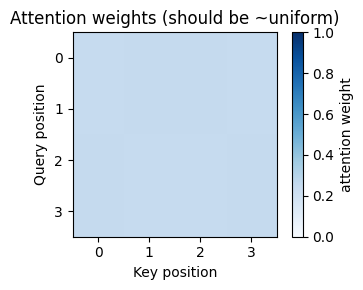


Attention matrix:
[[0.25  0.25  0.251 0.249]
 [0.25  0.25  0.25  0.25 ]
 [0.25  0.25  0.249 0.251]
 [0.25  0.25  0.25  0.25 ]]


In [21]:
# --- Visualise attention weights for that example ---
import math

with torch.no_grad():
    Q = x_ex @ model.W_q
    K = x_ex @ model.W_k
    E = (Q @ K.T) / math.sqrt(model.D_q)
    A = F.softmax(E, dim=-1)          # (SEQ_LEN, SEQ_LEN)

plt.figure(figsize=(4, 3))
plt.imshow(A.numpy(), vmin=0, vmax=1, cmap='Blues')
plt.colorbar(label='attention weight')
plt.xlabel('Key position')
plt.ylabel('Query position')
plt.title('Attention weights (should be ~uniform)')
plt.tight_layout()
plt.show()

print("\nAttention matrix:")
print(A.numpy().round(3))